# Random Forest Classifier

In [1]:
# Import libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

In [2]:
data = pd.read_csv("/Users/parthajit/Desktop/InterIIT/ZeltaLab_InterIIT/InterIIT-CryptoTrading/btcusdt_1h.csv")
data.head()

,datetime,open,high,low,close,volume
0,2018-01-01 05:30:00,13715.65,13715.65,13400.01,13529.01,443.356199
1,2018-01-01 06:30:00,13528.99,13595.89,13155.38,13203.06,383.697006
2,2018-01-01 07:30:00,13203.00,13418.43,13200.00,13330.18,429.064572
3,2018-01-01 08:30:00,13330.26,13611.27,13290.00,13410.03,420.087030
4,2018-01-01 09:30:00,13434.98,13623.29,13322.15,13601.01,340.807329


In [3]:
data.tail()


,datetime,open,high,low,close,volume
35203,2022-01-12 01:30:00,42972.04,43095.26,42692.19,42800.38,1219.60178
35204,2022-01-12 02:30:00,42797.62,42823.69,42643.74,42659.20,702.10380
35205,2022-01-12 03:30:00,42664.71,42776.14,42597.41,42713.13,561.85993
35206,2022-01-12 04:30:00,42713.12,42886.28,42633.97,42729.29,681.14201
35207,2022-01-12 05:30:00,42729.29,42965.00,42578.02,42675.00,1004.90689


In [4]:
# Features construction
data['Open-Close'] = (data.open - data.close)/data.open
data['High-Low'] = (data.high - data.low)/data.low
data['percent_change'] = data['close'].pct_change()
data['std_5'] = data['percent_change'].rolling(5).std()
data['ret_5'] = data['percent_change'].rolling(5).mean()
data.dropna(inplace=True)

# X is the input variable
X = data[['Open-Close', 'High-Low', 'std_5', 'ret_5']]

# Y is the target or output variable
y = np.where(data['close'].shift(-1) > data['close'], 1, -1)

In [5]:
# Total dataset length
dataset_length = data.shape[0]

# Training dataset length
split = int(dataset_length * 0.75)
split

26402

In [6]:
# Splitiing the X and y into train and test datasets
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Print the size of the train and test dataset
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(26402, 4) (8801, 4)
(26402,) (8801,)


In [7]:
# Create the model on train dataset
clf = RandomForestClassifier()  # Create a RandomForestClassifier instance

model = clf.fit(X_train, y_train)
from sklearn.metrics import accuracy_score
print('Correct Prediction (%): ', accuracy_score(y_test, model.predict(X_test), normalize=True)*100.0)

# Run the code to view the classification report metrics
from sklearn.metrics import classification_report
report = classification_report(y_test, model.predict(X_test))
print(report)

Correct Prediction (%):  50.89194409726168
              precision    recall  f1-score   support

          -1       0.51      0.48      0.49      4377
           1       0.51      0.54      0.52      4424

    accuracy                           0.51      8801
   macro avg       0.51      0.51      0.51      8801
weighted avg       0.51      0.51      0.51      8801



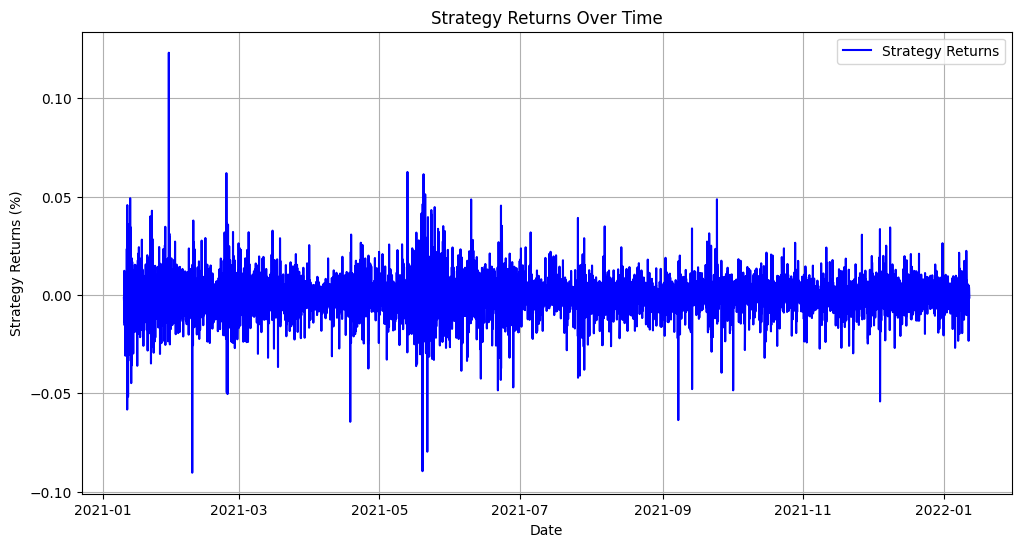

In [8]:
# Plot strategy returns along with the date on the x-axis
data['Date'] = pd.to_datetime(data['datetime'])  # Convert the 'Date' column to datetime
data['strategy_returns'] = data.percent_change.shift(-1) * model.predict(X)
plt.figure(figsize=(12, 6))  # Set the figure size
plt.plot(data['Date'][split:], data['strategy_returns'][split:], label='Strategy Returns', color='blue')
plt.xlabel('Date')
plt.ylabel('Strategy Returns (%)')
plt.title('Strategy Returns Over Time')
plt.legend()
plt.grid(True)
plt.show()


## Integrated SMA with Random Forest

(26402, 4) (8801, 4)
(26402,) (8801,)
Correct Prediction (%):  51.28962617884332
              precision    recall  f1-score   support

          -1       0.51      0.48      0.50      4377
           1       0.51      0.55      0.53      4424

    accuracy                           0.51      8801
   macro avg       0.51      0.51      0.51      8801
weighted avg       0.51      0.51      0.51      8801

First 20 Combined Signals: [0, -1, -1, 0, -1, -1, -1, -1, 0, 0, -1, 0, 0, 0, 0, 0, -1, -1, 0, 0]


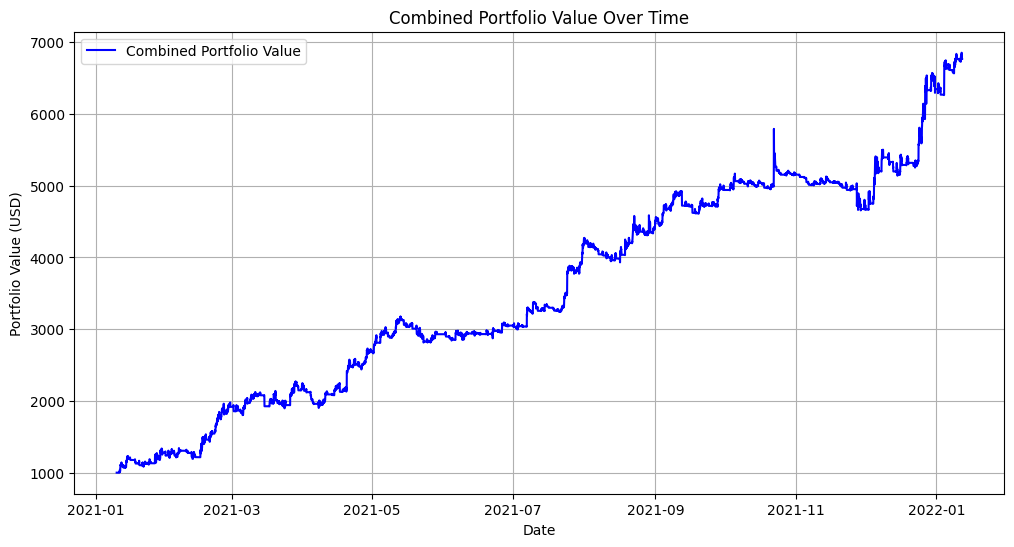

Final Combined Portfolio Value: $6771.19
Maximum Drawdown: -19.62%
Sharpe Ratio: -2.9836
Sortino Ratio: -3.5923


In [9]:
# Random Forest Classifier
# Import libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

data = pd.read_csv("/Users/parthajit/Desktop/InterIIT/ZeltaLab_InterIIT/InterIIT-CryptoTrading/btcusdt_1h.csv")
data.head()

data.tail()

# Features construction
data['Open-Close'] = (data.open - data.close) / data.open
data['High-Low'] = (data.high - data.low) / data.low
data['percent_change'] = data['close'].pct_change()
data['std_5'] = data['percent_change'].rolling(5).std()
data['ret_5'] = data['percent_change'].rolling(5).mean()
data.dropna(inplace=True)

# X is the input variable
X = data[['Open-Close', 'High-Low', 'std_5', 'ret_5']]

# Y is the target or output variable
y = np.where(data['close'].shift(-1) > data['close'], 1, -1)

# Total dataset length
dataset_length = data.shape[0]

# Training dataset length
split = int(dataset_length * 0.75)
split

# Splitting the X and y into train and test datasets
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Print the size of the train and test dataset
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

# Create the model on train dataset
clf = RandomForestClassifier()  # Create a RandomForestClassifier instance

model = clf.fit(X_train, y_train)
from sklearn.metrics import accuracy_score
print('Correct Prediction (%): ', accuracy_score(y_test, model.predict(X_test), normalize=True) * 100.0)

# Run the code to view the classification report metrics
from sklearn.metrics import classification_report
report = classification_report(y_test, model.predict(X_test))
print(report)

# Apply the strategy logic - Hold stock between -0.25% and 0.25%
data['Date'] = pd.to_datetime(data['datetime'])  # Convert the 'Date' column to datetime
data['strategy_returns'] = data.percent_change.shift(-1) * model.predict(X)

# Define the threshold values
lower_threshold = -0.001  # -0.25% as decimal
upper_threshold = 0.001   # 0.25% as decimal

# Apply the strategy logic
data['strategy_returns'] = np.where(
    (data['strategy_returns'] >= lower_threshold) & (data['strategy_returns'] <= upper_threshold),
    0,  # Hold stock
    data['strategy_returns']  # Proceed as usual
)

# Portfolio simulation
starting_capital = 1000  # Starting capital in USD
portfolio_value = [starting_capital]  # List to store portfolio value over time
# Define bitcoin_prices as the closing price from your data
bitcoin_prices = data['close']

# Initialize variables
current_cash = starting_capital
bitcoin_purchased = 0
portfolio_value = [starting_capital]

# Calculate SMA for a specific window size (e.g., 20 periods)
sma_window = 20
data['SMA'] = data['close'].rolling(sma_window).mean()

# Generate SMA signals (1 for buy, -1 for sell)
data['SMA_Signal'] = np.where(data['close'] > data['SMA'], 1, -1)

# Combine signals (1 for buy, -1 for sell) from the random forest and SMA strategies
data['Combined_Signal'] = (model.predict(X) + data['SMA_Signal']) / 2

# Initialize variables for the combined strategy
current_cash = starting_capital
bitcoin_purchased = 0
portfolio_value_combined = [starting_capital]

# Initialize a list to store signals
signal_list = []

# Define the transaction cost as a percentage
transaction_cost_percentage = 0.001  # 0.1%

# Update the loop for portfolio simulation using the combined signal
for i in range(len(data['Combined_Signal'])):
    combined_signal = data['Combined_Signal'].iloc[i]
    current_price = bitcoin_prices.iloc[i]

    # Append the combined signal to the list
    signal_list.append(int(combined_signal))

    if combined_signal > 0:
        # Buy Bitcoin with all available cash, considering transaction cost
        bitcoin_purchased += (current_cash / current_price) * (1 - transaction_cost_percentage)
        current_cash = 0
    elif combined_signal < 0:
        # Sell all Bitcoin and add to cash, considering transaction cost
        current_cash += (bitcoin_purchased * current_price) * (1 - transaction_cost_percentage)
        bitcoin_purchased = 0

    # Calculate portfolio value at this time step
    portfolio_value_combined.append(current_cash + bitcoin_purchased * current_price)

# Print the first 20 elements of the signal list
print('First 20 Combined Signals:', signal_list[:20])

portfolio_length = len(data) - split
portfolio_value_combined_adjusted = portfolio_value_combined[:portfolio_length]

portfolio_data = data.iloc[split:].copy()
portfolio_data['Portfolio_Value'] = portfolio_value_combined_adjusted

# Plot the portfolio value over time for the combined strategy
plt.figure(figsize=(12, 6))
plt.plot(portfolio_data['Date'], portfolio_data['Portfolio_Value'], label='Combined Portfolio Value', color='blue')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.title('Combined Portfolio Value Over Time')
plt.legend()
plt.grid(True)
plt.show()

# Print the final portfolio value for the combined strategy
final_portfolio_value_combined = portfolio_value_combined_adjusted[-1]
print('Final Combined Portfolio Value: ${:.2f}'.format(final_portfolio_value_combined))




portfolio_values = portfolio_data['Portfolio_Value']
peak_value = portfolio_values.cummax()
drawdown = (portfolio_values - peak_value) / peak_value
max_drawdown = drawdown.min()

print('Maximum Drawdown: {:.2%}'.format(max_drawdown))
avg_return = portfolio_values.pct_change().mean()
risk_free_rate = 0.02
std_dev = portfolio_values.pct_change().std()

sharpe_ratio = (avg_return - risk_free_rate) / std_dev

print('Sharpe Ratio: {:.4f}'.format(sharpe_ratio))
downside_returns = portfolio_values.pct_change()
downside_returns = downside_returns[downside_returns < 0]

avg_return = downside_returns.mean()
downside_std_dev = downside_returns.std()

sortino_ratio = (avg_return - risk_free_rate) / downside_std_dev

print('Sortino Ratio: {:.4f}'.format(sortino_ratio))



# Incorporating Z-Score, SMA, Random Forest

(26402, 4) (8801, 4)
(26402,) (8801,)
Correct Prediction (%):  51.18736507215089
              precision    recall  f1-score   support

          -1       0.51      0.47      0.49      4377
           1       0.51      0.55      0.53      4424

    accuracy                           0.51      8801
   macro avg       0.51      0.51      0.51      8801
weighted avg       0.51      0.51      0.51      8801

First 20 Combined Signals: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


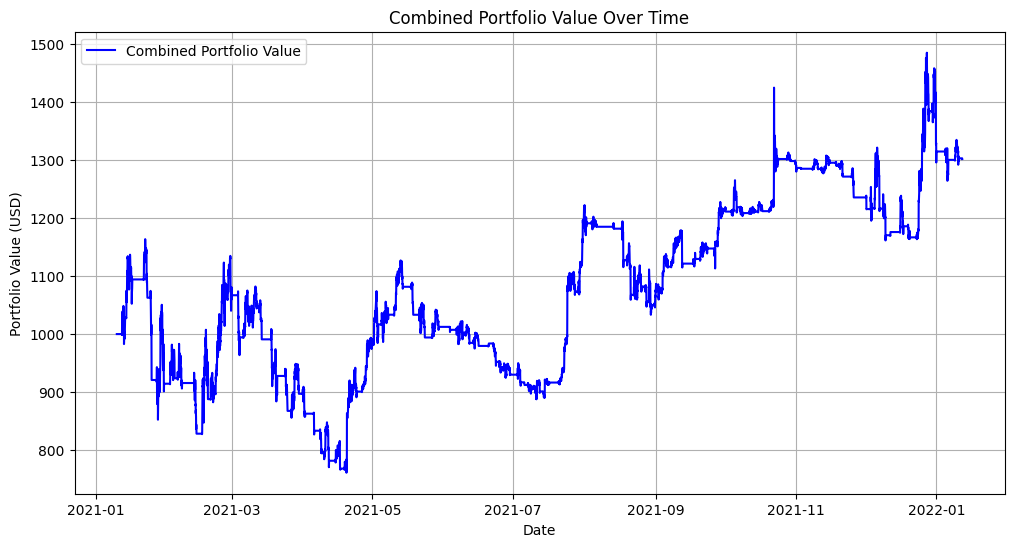

Final Combined Portfolio Value: $1301.85
30.1853426826081
Maximum Drawdown: 34.62%
Sortino Ratio: -0.0042
Sharpe Ratio: -0.0048


In [10]:
# Random Forest Classifier
# Import libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

data = pd.read_csv("/Users/parthajit/Desktop/InterIIT/ZeltaLab_InterIIT/InterIIT-CryptoTrading/btcusdt_1h.csv")
data.head()

data.tail()

# Features construction
data['Open-Close'] = (data.open - data.close) / data.open
data['High-Low'] = (data.high - data.low) / data.low
data['percent_change'] = data['close'].pct_change()
data['std_5'] = data['percent_change'].rolling(5).std()
data['ret_5'] = data['percent_change'].rolling(5).mean()
data.dropna(inplace=True)

# X is the input variable
X = data[['Open-Close', 'High-Low', 'std_5', 'ret_5']]

# Y is the target or output variable
y = np.where(data['close'].shift(-1) > data['close'], 1, -1)

# Total dataset length
dataset_length = data.shape[0]

# Training dataset length
split = int(dataset_length * 0.75)
split

# Splitting the X and y into train and test datasets
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Print the size of the train and test dataset
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

# Create the model on train dataset
clf = RandomForestClassifier()  # Create a RandomForestClassifier instance

model = clf.fit(X_train, y_train)
from sklearn.metrics import accuracy_score
print('Correct Prediction (%): ', accuracy_score(y_test, model.predict(X_test), normalize=True) * 100.0)

# Run the code to view the classification report metrics
from sklearn.metrics import classification_report
report = classification_report(y_test, model.predict(X_test))
print(report)

# Apply the strategy logic - Hold stock between -0.25% and 0.25%
data['Date'] = pd.to_datetime(data['datetime'])  # Convert the 'Date' column to datetime
data['strategy_returns'] = data.percent_change.shift(-1) * model.predict(X)

# Define the threshold values
lower_threshold = -0.001  # -0.25% as decimal
upper_threshold = 0.001   # 0.25% as decimal

# Apply the strategy logic
data['strategy_returns'] = np.where(
    (data['strategy_returns'] >= lower_threshold) & (data['strategy_returns'] <= upper_threshold),
    0,  # Hold stock
    data['strategy_returns']  # Proceed as usual
)

# Portfolio simulation
starting_capital = 1000  # Starting capital in USD
portfolio_value = [starting_capital]  # List to store portfolio value over time
# Define bitcoin_prices as the closing price from your data
bitcoin_prices = data['close']



# Calculate SMA for a specific window size (e.g., 24 periods)
# sma_window = 24
# data['SMA'] = data['close'].rolling(sma_window).mean()

# # Generate SMA signals (1 for buy, -1 for sell)
# data['SMA_Signal'] = np.where(data['close'] > data['SMA'], 1, -1)

# Define the long and short SMA window sizes
long_sma_window = 50
short_sma_window = 20

# Calculate the long and short SMAs
data['Long_SMA'] = data['close'].rolling(long_sma_window).mean()
data['Short_SMA'] = data['close'].rolling(short_sma_window).mean()

# Generate the SMA signal based on the comparison of long and short SMAs
data['SMA_Signal'] = np.where(data['Short_SMA'] > data['Long_SMA'], 1, -1)




# Initialize variables for the combined strategy
current_cash = starting_capital
bitcoin_purchased = 0
portfolio_value_combined = [starting_capital]

# Initialize a list to store signals
signal_list = []

# Define the transaction cost as a percentage
transaction_cost_percentage = 0.001  # 0.1%





# Calculate the Z-score for the closing price
z_score_window = 24*20 # Choose a suitable window size
data['Z_Score'] = (data['close'] - data['close'].rolling(z_score_window).mean()) / data['close'].rolling(z_score_window).std()
# Define Z-score thresholds
buy_threshold = 2.50  # You can adjust this threshold
sell_threshold = -2.50  # You can adjust this threshold
# Generate Z-score signals (1 for buy, -1 for sell, 0 for hold)
data['Z_Score_Signal'] = np.where(data['Z_Score'] > buy_threshold, 1, np.where(data['Z_Score'] < sell_threshold, -1, 0))
# Combine signals from your existing strategy and the Z-score
data['Combined_Signal'] = (model.predict(X) + data['SMA_Signal'] + data['Z_Score_Signal']) /3 # You can adjust the weights if needed/ model.predict(X) /data['Z_Score_Signal']




# Update the loop for portfolio simulation using the combined signal
for i in range(len(data['Combined_Signal'])):
    combined_signal = data['Combined_Signal'].iloc[i]
    current_price = bitcoin_prices.iloc[i]

    # Append the combined signal to the list
    signal_list.append(int(combined_signal))

    if combined_signal > 0:
        # if current_cash > 2000 :
        # # Buy Bitcoin with available cash, considering transaction cost
        #   bitcoin_purchased += (2000 / current_price) * (1 - transaction_cost_percentage)
        #   current_cash -= 2000
        # else :
          bitcoin_purchased += (current_cash / current_price) * (1 - transaction_cost_percentage)
          current_cash =0
    elif combined_signal < 0:
        # Sell all Bitcoin and add to cash, considering transaction cost
        current_cash += (bitcoin_purchased * current_price) * (1 - transaction_cost_percentage)
        bitcoin_purchased = 0


    # Calculate portfolio value at this time step
    portfolio_value_combined.append(current_cash + bitcoin_purchased * current_price)

# Print the first 20 elements of the signal list
print('First 20 Combined Signals:', signal_list[:20])

portfolio_length = len(data) - split
portfolio_value_combined_adjusted = portfolio_value_combined[:portfolio_length]

portfolio_data = data.iloc[split:].copy()
portfolio_data['Portfolio_Value'] = portfolio_value_combined_adjusted

# Plot the portfolio value over time for the combined strategy
plt.figure(figsize=(12, 6))
plt.plot(portfolio_data['Date'], portfolio_data['Portfolio_Value'], label='Combined Portfolio Value', color='blue')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.title('Combined Portfolio Value Over Time')
plt.legend()
plt.grid(True)
plt.show()

# Print the final portfolio value for the combined strategy
final_portfolio_value_combined = portfolio_value_combined_adjusted[-1]
print('Final Combined Portfolio Value: ${:.2f}'.format(final_portfolio_value_combined))
print((final_portfolio_value_combined-starting_capital)*100/starting_capital)




# Calculate drawdown
portfolio_values = portfolio_data['Portfolio_Value']
peak_value = portfolio_values.cummax()
drawdown = -(portfolio_values - peak_value) / peak_value
max_drawdown = drawdown.max()

print('Maximum Drawdown: {:.2%}'.format(max_drawdown))

# Calculate average return, downside returns, and downside standard deviation for Sortino ratio
daily_returns = portfolio_values.pct_change()
average_return = daily_returns.mean()
downside_returns = daily_returns[daily_returns < 0]
downside_std_dev = downside_returns.std()

# Calculate daily risk-free rate from the annual rate (adjust as needed)
annual_risk_free_rate = 0.02  # Adjust to your desired annual risk-free rate
daily_risk_free_rate = (1 + annual_risk_free_rate) ** (1/252) - 1

# Calculate Sortino ratio with the appropriate daily risk-free rate
sortino_ratio = (average_return - daily_risk_free_rate) / downside_std_dev

print('Sortino Ratio: {:.4f}'.format(sortino_ratio))

# Calculate Sharpe ratio with the appropriate daily risk-free rate
sharpe_ratio = (average_return - daily_risk_free_rate) / daily_returns.std()

print('Sharpe Ratio: {:.4f}'.format(sharpe_ratio))





In [11]:
signal_list

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [12]:
len(data['Combined_Signal'])

35203

In [13]:
data

,datetime,open,high,low,close,volume,Open-Close,High-Low,percent_change,std_5,ret_5,Date,strategy_returns,Long_SMA,Short_SMA,SMA_Signal,Z_Score,Z_Score_Signal,Combined_Signal
5,2018-01-01 10:30:00,13615.20,13699.00,13526.50,13558.99,404.229046,0.004128,0.012753,-0.003089,0.015166,0.000536,2018-01-01 10:30:00,0.016330,NaN,NaN,-1,NaN,0,0.000000
6,2018-01-01 11:30:00,13539.00,13800.00,13510.00,13780.41,264.989684,-0.017831,0.021466,0.016330,0.007683,0.008620,2018-01-01 11:30:00,0.015243,NaN,NaN,-1,NaN,0,-0.666667
7,2018-01-01 12:30:00,13780.00,13818.55,13555.02,13570.35,292.188777,0.015214,0.019442,-0.015243,0.013046,0.003646,2018-01-01 12:30:00,0.005185,NaN,NaN,-1,NaN,0,-0.666667
8,2018-01-01 13:30:00,13569.98,13735.24,13400.00,13499.99,271.813553,0.005158,0.025018,-0.005185,0.013494,0.001411,2018-01-01 13:30:00,0.008667,NaN,NaN,-1,NaN,0,0.000000
9,2018-01-01 14:30:00,13499.97,13670.00,13459.11,13616.99,213.095829,-0.008668,0.015669,0.008667,0.012350,0.000296,2018-01-01 14:30:00,0.003450,NaN,NaN,-1,NaN,0,-0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35203,2022-01-12 01:30:00,42972.04,43095.26,42692.19,42800.38,1219.601780,0.003995,0.009441,-0.003995,0.011066,0.005108,2022-01-12 01:30:00,0.003299,41902.5916,42160.0340,1,-1.130053,0,0.000000
35204,2022-01-12 02:30:00,42797.62,42823.69,42643.74,42659.20,702.103800,0.003234,0.004220,-0.003299,0.004723,-0.000207,2022-01-12 02:30:00,0.001264,41901.8704,42196.5530,1,-1.168407,0,0.666667
35205,2022-01-12 03:30:00,42664.71,42776.14,42597.41,42713.13,561.859930,-0.001135,0.004196,0.001264,0.004319,0.000778,2022-01-12 03:30:00,0.000000,41907.3454,42223.5210,1,-1.146986,0,0.666667
35206,2022-01-12 04:30:00,42713.12,42886.28,42633.97,42729.29,681.142010,-0.000379,0.005918,0.000378,0.003684,-0.000115,2022-01-12 04:30:00,-0.001271,41915.9312,42246.0865,1,-1.137258,0,0.666667


In [14]:
data['Combined_Signal']

test_list = data['Combined_Signal'].tolist()

for i in range(0,len(test_list)):
    if test_list[i]==-1:
        test_list[i]=-1
    elif test_list[i]==1:
        test_list[i]=1
    else:
        test_list[i]=0
        
test_list


signal_list = test_list


signal_list


[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [15]:
data['signal_list'] = signal_list

data

,datetime,open,high,low,close,volume,Open-Close,High-Low,percent_change,std_5,ret_5,Date,strategy_returns,Long_SMA,Short_SMA,SMA_Signal,Z_Score,Z_Score_Signal,Combined_Signal,signal_list
5,2018-01-01 10:30:00,13615.20,13699.00,13526.50,13558.99,404.229046,0.004128,0.012753,-0.003089,0.015166,0.000536,2018-01-01 10:30:00,0.016330,NaN,NaN,-1,NaN,0,0.000000,0
6,2018-01-01 11:30:00,13539.00,13800.00,13510.00,13780.41,264.989684,-0.017831,0.021466,0.016330,0.007683,0.008620,2018-01-01 11:30:00,0.015243,NaN,NaN,-1,NaN,0,-0.666667,0
7,2018-01-01 12:30:00,13780.00,13818.55,13555.02,13570.35,292.188777,0.015214,0.019442,-0.015243,0.013046,0.003646,2018-01-01 12:30:00,0.005185,NaN,NaN,-1,NaN,0,-0.666667,0
8,2018-01-01 13:30:00,13569.98,13735.24,13400.00,13499.99,271.813553,0.005158,0.025018,-0.005185,0.013494,0.001411,2018-01-01 13:30:00,0.008667,NaN,NaN,-1,NaN,0,0.000000,0
9,2018-01-01 14:30:00,13499.97,13670.00,13459.11,13616.99,213.095829,-0.008668,0.015669,0.008667,0.012350,0.000296,2018-01-01 14:30:00,0.003450,NaN,NaN,-1,NaN,0,-0.666667,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35203,2022-01-12 01:30:00,42972.04,43095.26,42692.19,42800.38,1219.601780,0.003995,0.009441,-0.003995,0.011066,0.005108,2022-01-12 01:30:00,0.003299,41902.5916,42160.0340,1,-1.130053,0,0.000000,0
35204,2022-01-12 02:30:00,42797.62,42823.69,42643.74,42659.20,702.103800,0.003234,0.004220,-0.003299,0.004723,-0.000207,2022-01-12 02:30:00,0.001264,41901.8704,42196.5530,1,-1.168407,0,0.666667,0
35205,2022-01-12 03:30:00,42664.71,42776.14,42597.41,42713.13,561.859930,-0.001135,0.004196,0.001264,0.004319,0.000778,2022-01-12 03:30:00,0.000000,41907.3454,42223.5210,1,-1.146986,0,0.666667,0
35206,2022-01-12 04:30:00,42713.12,42886.28,42633.97,42729.29,681.142010,-0.000379,0.005918,0.000378,0.003684,-0.000115,2022-01-12 04:30:00,-0.001271,41915.9312,42246.0865,1,-1.137258,0,0.666667,0


In [16]:


def returns(signals,timeseries):
    investment=1000
    long=[]
    long_price=[]
    short_price=[]
    short=[]
    cum_pnl_timely=[]
    for i in range(len(signals)):
        if signals[i]==1:
            long.append(i)
            long_price.append(timeseries[i])
        elif signals[i]==-1:
            short.append(i)
            short_price.append(timeseries[i])
    cum_pnl=0
    while len(long)!=0 and len(short)!=0:
        if short[0]<long[0]:
            while short[0]<long[0]:
                cum_pnl+=(short_price[0]-long_price[0])*investment/short_price[0]-0.1/100*investment
                cum_pnl_timely.append(cum_pnl)
                short.pop(0)
                short_price.pop(0)
                if len(short)==0 or len(long)==0:
                    break
            long.pop(0)
            long_price.pop(0) 
        elif long[0]<short[0]:
            while short[0]>long[0]:
                cum_pnl+=(short_price[0]-long_price[0])*investment/long_price[0]-0.1/100*investment
                cum_pnl_timely.append(cum_pnl)
                long.pop(0)
                long_price.pop(0)
                if len(short)==0 or len(long)==0:
                    break
            short.pop(0)
            short_price.pop(0) 
            
    return cum_pnl,cum_pnl_timely


cum_pnl ,cum_pnl_timely =returns(signal_list,data['close'].to_list())

print(cum_pnl)
len(cum_pnl_timely)


373466.45420089783


1015

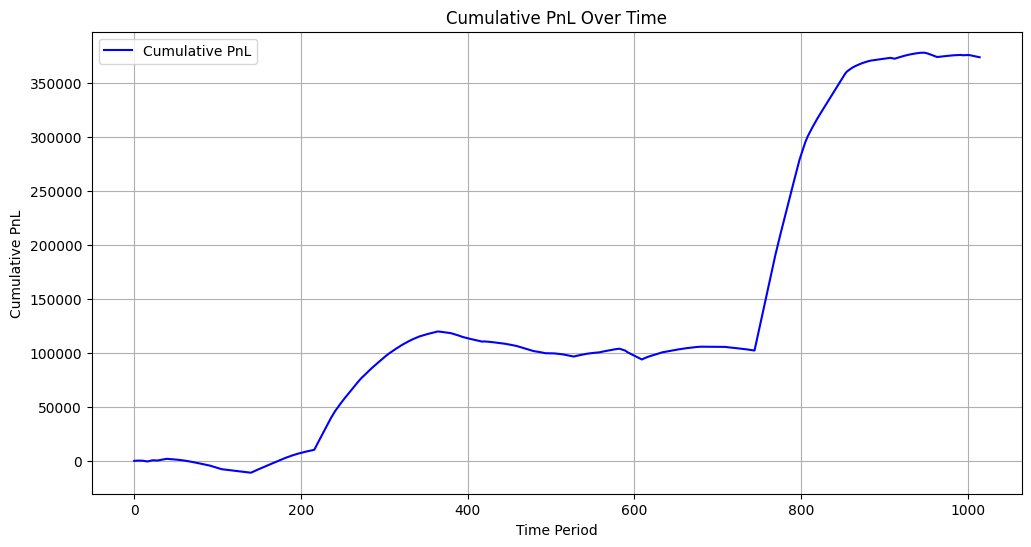

In [17]:
import matplotlib.pyplot as plt

cum_pnl_timely# Your list of cumulative PnL values

# Create a list of time periods (assuming one period per PnL update)
time_periods = list(range(len(cum_pnl_timely)))

# Plot cumulative PnL over time
plt.figure(figsize=(12, 6))
plt.plot(time_periods, cum_pnl_timely, label='Cumulative PnL', color='blue')
plt.xlabel('Time Period')
plt.ylabel('Cumulative PnL')
plt.title('Cumulative PnL Over Time')
plt.grid(True)
plt.legend()
plt.show()


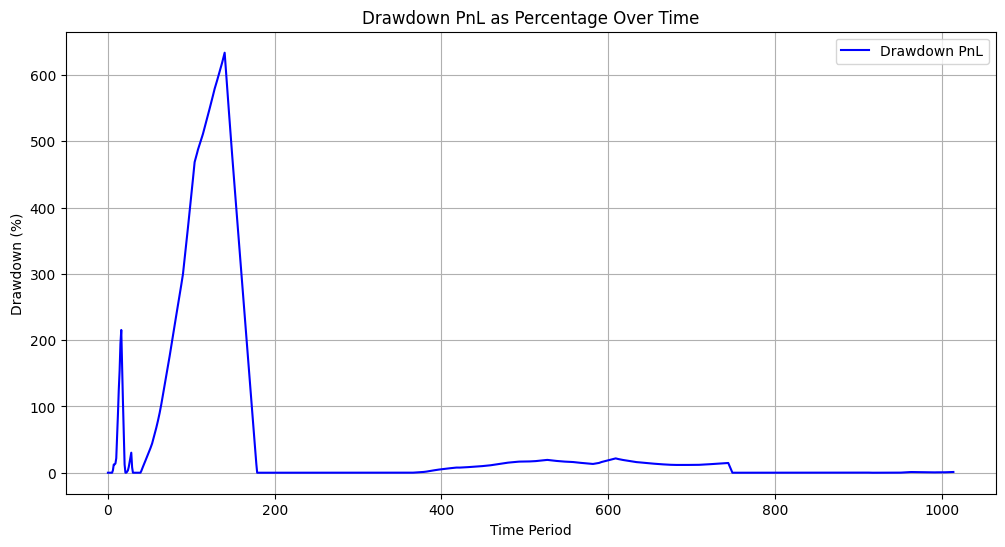

Max Drawdown : 633.7060624739225 %


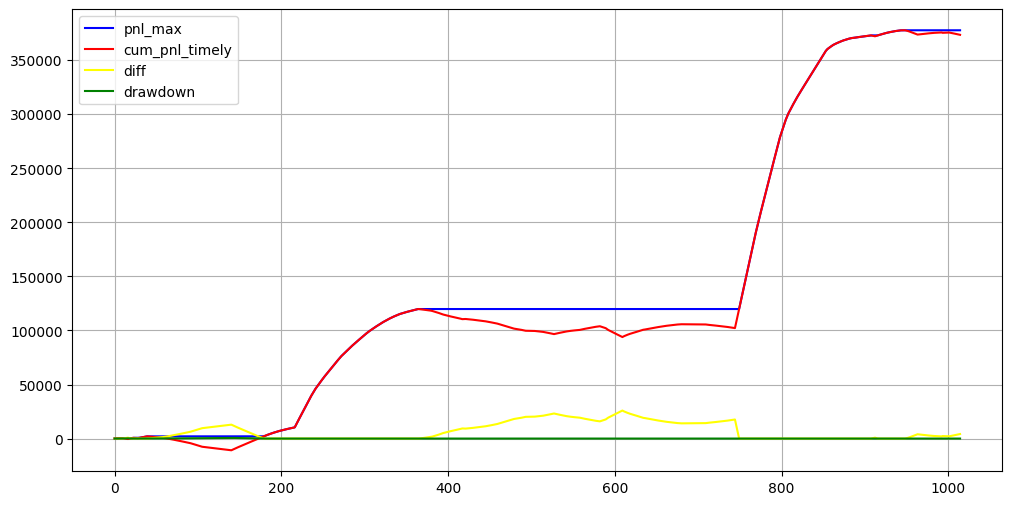

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Convert your list to a NumPy array
cum_pnl_timely = np.array(cum_pnl_timely)

# Calculate the cumulative maximum of PnL values
pnl_max = np.maximum.accumulate(cum_pnl_timely)

# Calculate drawdown as a percentage
drawdown_pnl = (pnl_max - cum_pnl_timely)*100 / pnl_max

# Create a list of time periods (assuming one period per PnL update)
time_periods = list(range(len(drawdown_pnl)))

# Plot drawdown PnL over time
plt.figure(figsize=(12, 6))
plt.plot(time_periods, drawdown_pnl, label='Drawdown PnL', color='blue')
plt.grid(True)
plt.legend()
plt.xlabel('Time Period')
plt.ylabel('Drawdown (%)')
plt.title('Drawdown PnL as Percentage Over Time')
plt.show()



print("Max Drawdown :", max(drawdown_pnl), "%")

import matplotlib.pyplot as plt

cum_pnl_timely# Your list of cumulative PnL values

# Create a list of time periods (assuming one period per PnL update)
time_periods = list(range(len(cum_pnl_timely)))

# Plot cumulative PnL over time
plt.figure(figsize=(12, 6))
plt.plot(time_periods, pnl_max, label='pnl_max', color='blue')
plt.plot(time_periods, cum_pnl_timely, label='cum_pnl_timely', color='red')
plt.plot(time_periods, pnl_max-cum_pnl_timely, label='diff', color='yellow')
plt.plot(time_periods, (pnl_max-cum_pnl_timely)*100/pnl_max, label='drawdown', color='green')
plt.grid(True)
plt.legend()
plt.show()



In [19]:
len(signal_list)

35203

In [20]:
data

,datetime,open,high,low,close,volume,Open-Close,High-Low,percent_change,std_5,ret_5,Date,strategy_returns,Long_SMA,Short_SMA,SMA_Signal,Z_Score,Z_Score_Signal,Combined_Signal,signal_list
5,2018-01-01 10:30:00,13615.20,13699.00,13526.50,13558.99,404.229046,0.004128,0.012753,-0.003089,0.015166,0.000536,2018-01-01 10:30:00,0.016330,NaN,NaN,-1,NaN,0,0.000000,0
6,2018-01-01 11:30:00,13539.00,13800.00,13510.00,13780.41,264.989684,-0.017831,0.021466,0.016330,0.007683,0.008620,2018-01-01 11:30:00,0.015243,NaN,NaN,-1,NaN,0,-0.666667,0
7,2018-01-01 12:30:00,13780.00,13818.55,13555.02,13570.35,292.188777,0.015214,0.019442,-0.015243,0.013046,0.003646,2018-01-01 12:30:00,0.005185,NaN,NaN,-1,NaN,0,-0.666667,0
8,2018-01-01 13:30:00,13569.98,13735.24,13400.00,13499.99,271.813553,0.005158,0.025018,-0.005185,0.013494,0.001411,2018-01-01 13:30:00,0.008667,NaN,NaN,-1,NaN,0,0.000000,0
9,2018-01-01 14:30:00,13499.97,13670.00,13459.11,13616.99,213.095829,-0.008668,0.015669,0.008667,0.012350,0.000296,2018-01-01 14:30:00,0.003450,NaN,NaN,-1,NaN,0,-0.666667,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35203,2022-01-12 01:30:00,42972.04,43095.26,42692.19,42800.38,1219.601780,0.003995,0.009441,-0.003995,0.011066,0.005108,2022-01-12 01:30:00,0.003299,41902.5916,42160.0340,1,-1.130053,0,0.000000,0
35204,2022-01-12 02:30:00,42797.62,42823.69,42643.74,42659.20,702.103800,0.003234,0.004220,-0.003299,0.004723,-0.000207,2022-01-12 02:30:00,0.001264,41901.8704,42196.5530,1,-1.168407,0,0.666667,0
35205,2022-01-12 03:30:00,42664.71,42776.14,42597.41,42713.13,561.859930,-0.001135,0.004196,0.001264,0.004319,0.000778,2022-01-12 03:30:00,0.000000,41907.3454,42223.5210,1,-1.146986,0,0.666667,0
35206,2022-01-12 04:30:00,42713.12,42886.28,42633.97,42729.29,681.142010,-0.000379,0.005918,0.000378,0.003684,-0.000115,2022-01-12 04:30:00,-0.001271,41915.9312,42246.0865,1,-1.137258,0,0.666667,0


In [21]:
final_df = pd.read_csv("btcusdt_1h.csv")

final_df

,datetime,open,high,low,close,volume
0,2018-01-01 05:30:00,13715.65,13715.65,13400.01,13529.01,443.356199
1,2018-01-01 06:30:00,13528.99,13595.89,13155.38,13203.06,383.697006
2,2018-01-01 07:30:00,13203.00,13418.43,13200.00,13330.18,429.064572
3,2018-01-01 08:30:00,13330.26,13611.27,13290.00,13410.03,420.087030
4,2018-01-01 09:30:00,13434.98,13623.29,13322.15,13601.01,340.807329
...,...,...,...,...,...,...
35203,2022-01-12 01:30:00,42972.04,43095.26,42692.19,42800.38,1219.601780
35204,2022-01-12 02:30:00,42797.62,42823.69,42643.74,42659.20,702.103800
35205,2022-01-12 03:30:00,42664.71,42776.14,42597.41,42713.13,561.859930
35206,2022-01-12 04:30:00,42713.12,42886.28,42633.97,42729.29,681.142010


In [22]:
import pandas as pd

# Merge dataframes based on the 'datetime' column, using a left join to keep all rows from final_df
merged_df = final_df.merge(data[['datetime', 'signal_list']], on='datetime', how='left')

# Fill missing values in the 'signal_list' column with 0
merged_df['signal_list'].fillna(0, inplace=True)

# Rename the column if needed
merged_df.rename(columns={'signal_list': 'signals'}, inplace=True)

# 'merged_df' now contains the new column with signal_list values matched by 'datetime'

merged_df

,datetime,open,high,low,close,volume,signals
0,2018-01-01 05:30:00,13715.65,13715.65,13400.01,13529.01,443.356199,0.0
1,2018-01-01 06:30:00,13528.99,13595.89,13155.38,13203.06,383.697006,0.0
2,2018-01-01 07:30:00,13203.00,13418.43,13200.00,13330.18,429.064572,0.0
3,2018-01-01 08:30:00,13330.26,13611.27,13290.00,13410.03,420.087030,0.0
4,2018-01-01 09:30:00,13434.98,13623.29,13322.15,13601.01,340.807329,0.0
...,...,...,...,...,...,...,...
35203,2022-01-12 01:30:00,42972.04,43095.26,42692.19,42800.38,1219.601780,0.0
35204,2022-01-12 02:30:00,42797.62,42823.69,42643.74,42659.20,702.103800,0.0
35205,2022-01-12 03:30:00,42664.71,42776.14,42597.41,42713.13,561.859930,0.0
35206,2022-01-12 04:30:00,42713.12,42886.28,42633.97,42729.29,681.142010,0.0


In [23]:
rsi_df = pd.read_csv("/Users/parthajit/Desktop/InterIIT/ZeltaLab_InterIIT/InterIIT-CryptoTrading/rsi_indicator.csv")


# Merge dataframes based on the 'datetime' column, using a left join to keep all rows from final_df
merged_df_2 = merged_df.merge(rsi_df[['datetime', 'position']], on='datetime', how='left')

# Fill missing values in the 'signal_list' column with 0
merged_df_2['position'].fillna(0, inplace=True)


# 'merged_df' now contains the new column with signal_list values matched by 'datetime'

merged_df_2

,datetime,open,high,low,close,volume,signals,position
0,2018-01-01 05:30:00,13715.65,13715.65,13400.01,13529.01,443.356199,0.0,0.0
1,2018-01-01 06:30:00,13528.99,13595.89,13155.38,13203.06,383.697006,0.0,0.0
2,2018-01-01 07:30:00,13203.00,13418.43,13200.00,13330.18,429.064572,0.0,0.0
3,2018-01-01 08:30:00,13330.26,13611.27,13290.00,13410.03,420.087030,0.0,0.0
4,2018-01-01 09:30:00,13434.98,13623.29,13322.15,13601.01,340.807329,0.0,0.0
...,...,...,...,...,...,...,...,...
35203,2022-01-12 01:30:00,42972.04,43095.26,42692.19,42800.38,1219.601780,0.0,0.0
35204,2022-01-12 02:30:00,42797.62,42823.69,42643.74,42659.20,702.103800,0.0,0.0
35205,2022-01-12 03:30:00,42664.71,42776.14,42597.41,42713.13,561.859930,0.0,0.0
35206,2022-01-12 04:30:00,42713.12,42886.28,42633.97,42729.29,681.142010,0.0,0.0


In [24]:
# merged_df_2['combined_signal'] = (merged_df_2['signals']+merged_df_2['position'])/2
merged_df_2['combined_signal'] = (merged_df_2['signals'])

# Replace 0.5 with 1 and -0.5 with -1 in the specified column
merged_df_2['combined_signal'] = np.where(merged_df_2['combined_signal'] > 0, 1, np.where(merged_df_2['combined_signal'] < 0, -1, 0))
# 'column_name' now contains the modified values

merged_df_2

,datetime,open,high,low,close,volume,signals,position,combined_signal
0,2018-01-01 05:30:00,13715.65,13715.65,13400.01,13529.01,443.356199,0.0,0.0,0
1,2018-01-01 06:30:00,13528.99,13595.89,13155.38,13203.06,383.697006,0.0,0.0,0
2,2018-01-01 07:30:00,13203.00,13418.43,13200.00,13330.18,429.064572,0.0,0.0,0
3,2018-01-01 08:30:00,13330.26,13611.27,13290.00,13410.03,420.087030,0.0,0.0,0
4,2018-01-01 09:30:00,13434.98,13623.29,13322.15,13601.01,340.807329,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...
35203,2022-01-12 01:30:00,42972.04,43095.26,42692.19,42800.38,1219.601780,0.0,0.0,0
35204,2022-01-12 02:30:00,42797.62,42823.69,42643.74,42659.20,702.103800,0.0,0.0,0
35205,2022-01-12 03:30:00,42664.71,42776.14,42597.41,42713.13,561.859930,0.0,0.0,0
35206,2022-01-12 04:30:00,42713.12,42886.28,42633.97,42729.29,681.142010,0.0,0.0,0


In [25]:
final_df

merged_df_2['combined_signal']

final_df['signals']= merged_df_2['combined_signal']

final_df

,datetime,open,high,low,close,volume,signals
0,2018-01-01 05:30:00,13715.65,13715.65,13400.01,13529.01,443.356199,0
1,2018-01-01 06:30:00,13528.99,13595.89,13155.38,13203.06,383.697006,0
2,2018-01-01 07:30:00,13203.00,13418.43,13200.00,13330.18,429.064572,0
3,2018-01-01 08:30:00,13330.26,13611.27,13290.00,13410.03,420.087030,0
4,2018-01-01 09:30:00,13434.98,13623.29,13322.15,13601.01,340.807329,0
...,...,...,...,...,...,...,...
35203,2022-01-12 01:30:00,42972.04,43095.26,42692.19,42800.38,1219.601780,0
35204,2022-01-12 02:30:00,42797.62,42823.69,42643.74,42659.20,702.103800,0
35205,2022-01-12 03:30:00,42664.71,42776.14,42597.41,42713.13,561.859930,0
35206,2022-01-12 04:30:00,42713.12,42886.28,42633.97,42729.29,681.142010,0


# Checking if everything is correct

In [26]:
final_df['signals']

0        0
1        0
2        0
3        0
4        0
        ..
35203    0
35204    0
35205    0
35206    0
35207    0
Name: signals, Length: 35208, dtype: int64

In [27]:
len(final_df['signals'])



35208

In [28]:
final_df['close']

close_list = final_df['close'].tolist()
len(close_list)

35208

In [38]:
# Assuming 'merged_df' is your DataFrame and 'new_column_name' is the name of the column you want to convert
test_list = final_df['signals'].tolist()

# 'test_list' will now contain the values of the specified column as a Python list


def returns(signals,timeseries):
    investment=1000
    long=[]
    long_price=[]
    short_price=[]
    short=[]
    cum_pnl_timely=[]
    for i in range(len(signals)):
        if signals[i]==1:
            long.append(i)
            long_price.append(timeseries[i])
        elif signals[i]==-1:
            short.append(i)
            short_price.append(timeseries[i])
    cum_pnl=0
    while len(long)!=0 and len(short)!=0:
        if short[0]<long[0]:
            while short[0]<long[0]:
                cum_pnl+=(short_price[0]-long_price[0])*investment/short_price[0]-0.1/100*investment
                cum_pnl_timely.append(cum_pnl)
                short.pop(0)
                short_price.pop(0)
                if len(short)==0 or len(long)==0:
                    break
            long.pop(0)
            long_price.pop(0) 
        elif long[0]<short[0]:
            while short[0]>long[0]:
                cum_pnl+=(short_price[0]-long_price[0])*investment/long_price[0]-0.1/100*investment
                cum_pnl_timely.append(cum_pnl)
                long.pop(0)
                long_price.pop(0)
                if len(short)==0 or len(long)==0:
                    break
            short.pop(0)
            short_price.pop(0) 
            
    return cum_pnl,cum_pnl_timely


cum_pnl ,cum_pnl_timely =returns(test_list,close_list)

print(cum_pnl)
len(cum_pnl_timely)


373466.45420089783


1015

In [39]:
test_list

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


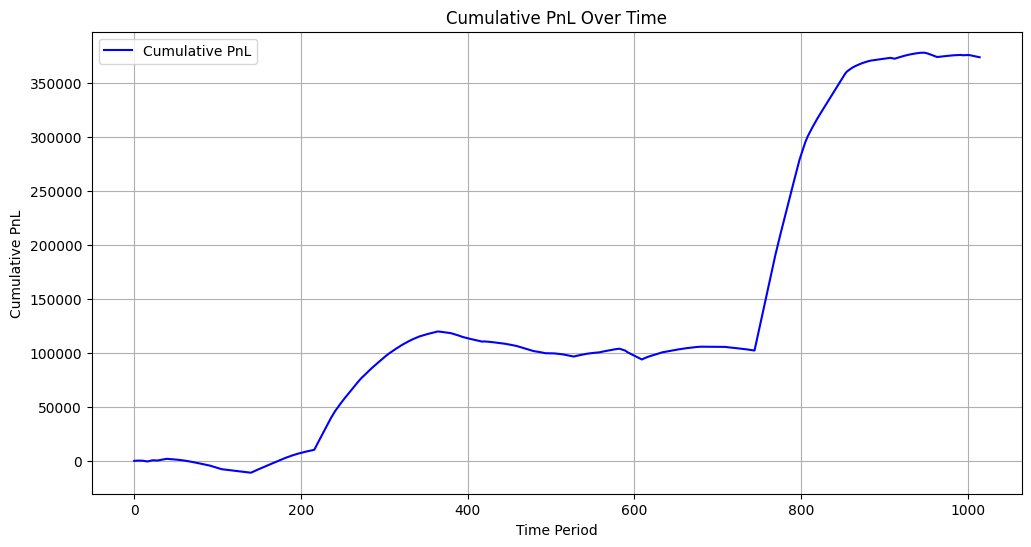

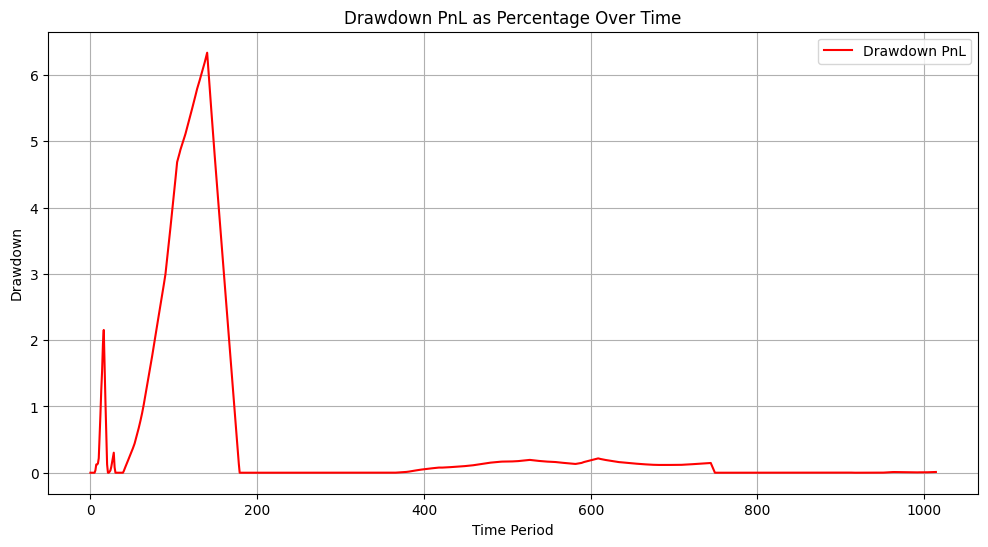

Max Drawdown : 6.337060624739225


In [40]:
import matplotlib.pyplot as plt

cum_pnl_timely# Your list of cumulative PnL values

# Create a list of time periods (assuming one period per PnL update)
time_periods = list(range(len(cum_pnl_timely)))

# Plot cumulative PnL over time
plt.figure(figsize=(12, 6))
plt.plot(time_periods, cum_pnl_timely, label='Cumulative PnL', color='blue')
plt.xlabel('Time Period')
plt.ylabel('Cumulative PnL')
plt.title('Cumulative PnL Over Time')
plt.grid(True)
plt.legend()



import numpy as np
import matplotlib.pyplot as plt

# Convert your list to a NumPy array
cum_pnl_timely = np.array(cum_pnl_timely)

# Calculate the cumulative maximum of PnL values
pnl_max = np.maximum.accumulate(cum_pnl_timely)

# Calculate drawdown as a percentage
drawdown_pnl = (pnl_max - cum_pnl_timely) / pnl_max

drawdown_pnl = abs(drawdown_pnl)

# Create a list of time periods (assuming one period per PnL update)
time_periods = list(range(len(drawdown_pnl)))

# Plot drawdown PnL over time
plt.figure(figsize=(12, 6))
plt.plot(time_periods, drawdown_pnl, label='Drawdown PnL', color='red')
plt.grid(True)
plt.legend()
plt.xlabel('Time Period')
plt.ylabel('Drawdown')
plt.title('Drawdown PnL as Percentage Over Time')
plt.show()



print("Max Drawdown :", max(drawdown_pnl))




# FINAL SUBMISSION

macd, aroon, fibonacci retracement, ichimoku cloud, mean reversion,on balance volume

In [41]:
final_df

,datetime,open,high,low,close,volume,signals
0,2018-01-01 05:30:00,13715.65,13715.65,13400.01,13529.01,443.356199,0
1,2018-01-01 06:30:00,13528.99,13595.89,13155.38,13203.06,383.697006,0
2,2018-01-01 07:30:00,13203.00,13418.43,13200.00,13330.18,429.064572,0
3,2018-01-01 08:30:00,13330.26,13611.27,13290.00,13410.03,420.087030,0
4,2018-01-01 09:30:00,13434.98,13623.29,13322.15,13601.01,340.807329,0
...,...,...,...,...,...,...,...
35203,2022-01-12 01:30:00,42972.04,43095.26,42692.19,42800.38,1219.601780,0
35204,2022-01-12 02:30:00,42797.62,42823.69,42643.74,42659.20,702.103800,0
35205,2022-01-12 03:30:00,42664.71,42776.14,42597.41,42713.13,561.859930,0
35206,2022-01-12 04:30:00,42713.12,42886.28,42633.97,42729.29,681.142010,0


In [43]:
final_df.to_csv("signals.csv",index = True)

## On-balance Volume

Arin-macd ; rutv- mean reversion; vardhman- fibonacci retracement; psrt- on balance volume; varun- aroon; amulya- ichimoku cloud

Take-Profit Targets : Risk

In [57]:
import pandas as pd

# Assuming you have final_df already defined
initial_df = final_df.copy()  # Create a copy of final_df

# Remove the 'signals' column from initial_df
initial_df.drop('signals', axis=1, inplace=True)

initial_df

,datetime,open,high,low,close,volume
0,2018-01-01 05:30:00,13715.65,13715.65,13400.01,13529.01,443.356199
1,2018-01-01 06:30:00,13528.99,13595.89,13155.38,13203.06,383.697006
2,2018-01-01 07:30:00,13203.00,13418.43,13200.00,13330.18,429.064572
3,2018-01-01 08:30:00,13330.26,13611.27,13290.00,13410.03,420.087030
4,2018-01-01 09:30:00,13434.98,13623.29,13322.15,13601.01,340.807329
...,...,...,...,...,...,...
35203,2022-01-12 01:30:00,42972.04,43095.26,42692.19,42800.38,1219.601780
35204,2022-01-12 02:30:00,42797.62,42823.69,42643.74,42659.20,702.103800
35205,2022-01-12 03:30:00,42664.71,42776.14,42597.41,42713.13,561.859930
35206,2022-01-12 04:30:00,42713.12,42886.28,42633.97,42729.29,681.142010


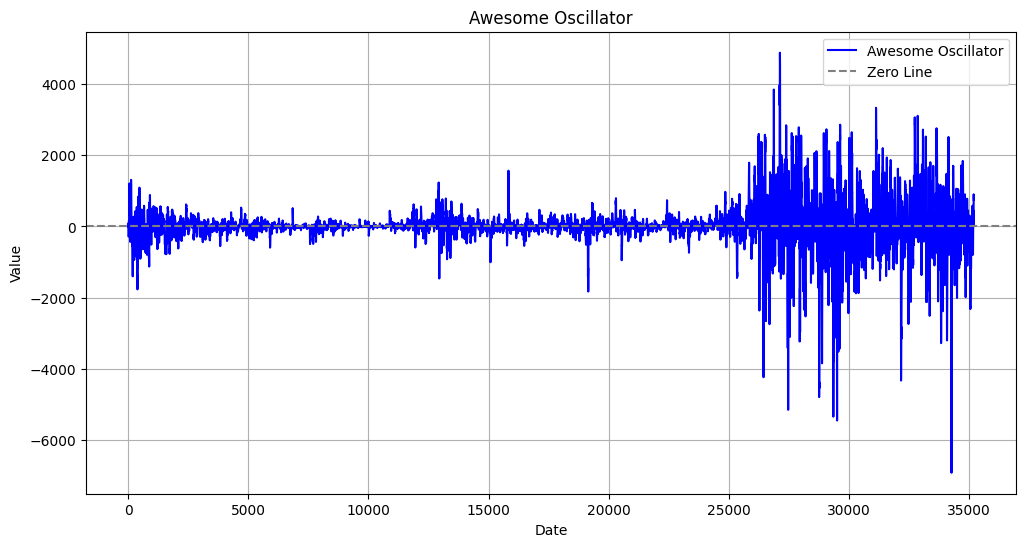

,Awesome Oscillator
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,0.000000
...,...
35203,850.827294
35204,904.393118
35205,858.061618
35206,827.983647


In [59]:
import pandas as pd
import matplotlib.pyplot as plt
from ta.momentum import AwesomeOscillatorIndicator

# Calculate the Awesome Oscillator for final_df
ao = AwesomeOscillatorIndicator(initial_df['high'], initial_df['low'], 5, 34, True)

# Access the Awesome Oscillator values
ao_values = ao.awesome_oscillator()

# Create a DataFrame to store the Awesome Oscillator values along with the index
ao_df = pd.DataFrame({
    'Awesome Oscillator': ao_values,
}, index=final_df.index)

# Plot the Awesome Oscillator values
plt.figure(figsize=(12, 6))
plt.plot(ao_df.index, ao_df['Awesome Oscillator'], label='Awesome Oscillator', color='blue')
plt.axhline(0, color='gray', linestyle='--', label='Zero Line')  # Add a horizontal line at zero for reference

plt.title('Awesome Oscillator')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


ao_df


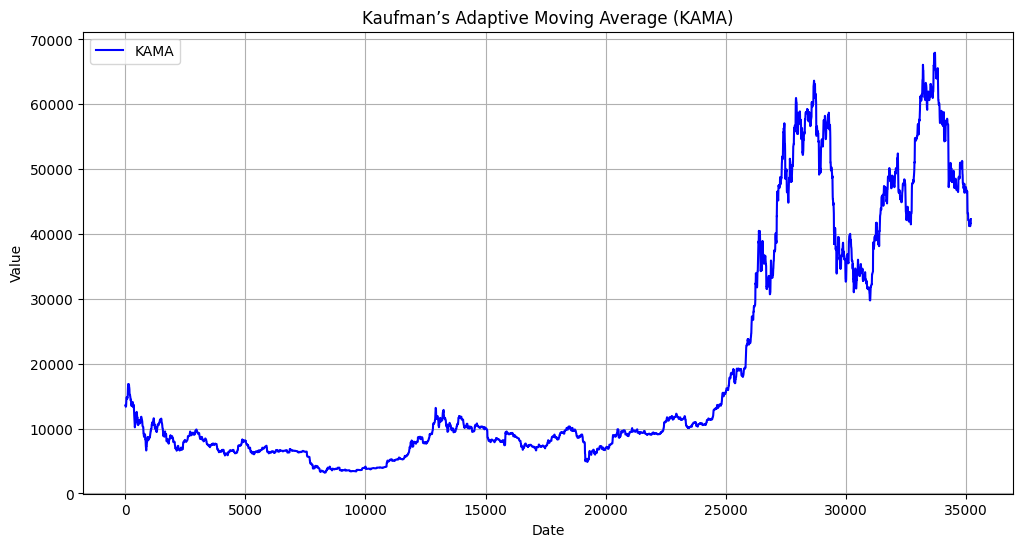

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from ta.momentum import KAMAIndicator

# Assuming you have initial_df already defined with a 'Close' column
# Calculate the KAMA indicator for initial_df
kama = KAMAIndicator(initial_df['close'], window=10, pow1=2, pow2=30, fillna=False)

# Access the KAMA values
kama_values = kama.kama()

# Create a DataFrame to store the KAMA values along with the index
kama_df = pd.DataFrame({
    'KAMA': kama_values,
}, index=initial_df.index)

# Plot the KAMA indicator
plt.figure(figsize=(12, 6))
plt.plot(kama_df.index, kama_df['KAMA'], label='KAMA', color='blue')

plt.title('Kaufman’s Adaptive Moving Average (KAMA)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


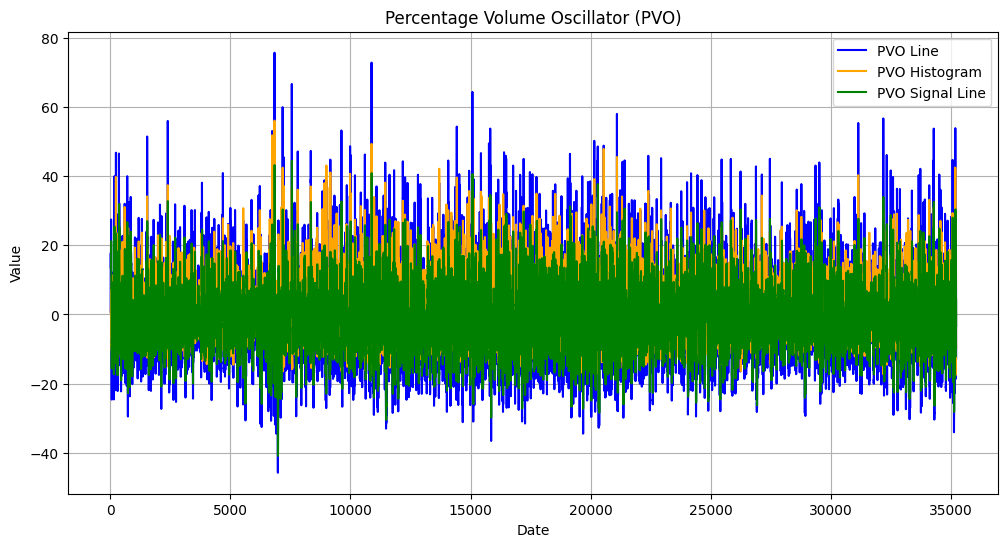

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from ta.momentum import PercentageVolumeOscillator

# Assuming you have initial_df already defined with a 'Volume' column
# Calculate the PVO indicator for initial_df
pvo = PercentageVolumeOscillator(
    volume=initial_df['volume'],
    window_slow=26,
    window_fast=12,
    window_sign=9,
    fillna=False
)

# Access the PVO line values, histogram values, and signal line values
pvo_line = pvo.pvo()
pvo_hist = pvo.pvo_hist()
pvo_signal = pvo.pvo_signal()

# Create a DataFrame to store the PVO indicator values along with the index
pvo_df = pd.DataFrame({
    'PVO Line': pvo_line,
    'PVO Histogram': pvo_hist,
    'PVO Signal Line': pvo_signal
}, index=initial_df.index)

# Plot the PVO indicator components
plt.figure(figsize=(12, 6))
plt.plot(pvo_df.index, pvo_df['PVO Line'], label='PVO Line', color='blue')
plt.plot(pvo_df.index, pvo_df['PVO Histogram'], label='PVO Histogram', color='orange')
plt.plot(pvo_df.index, pvo_df['PVO Signal Line'], label='PVO Signal Line', color='green')

plt.title('Percentage Volume Oscillator (PVO)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


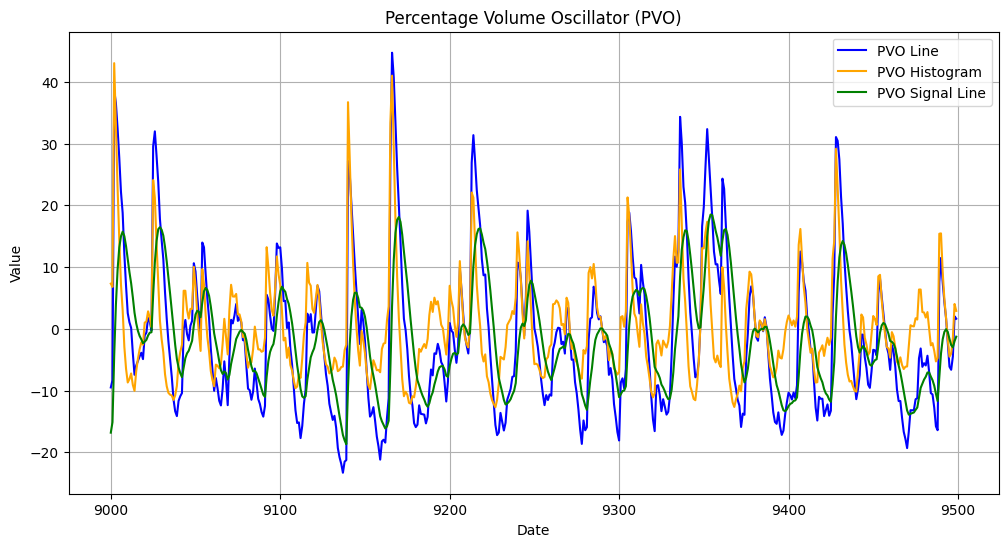

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
from ta.momentum import PercentageVolumeOscillator

# Assuming you have initial_df already defined with a 'Volume' column
# Calculate the PVO indicator for initial_df
pvo = PercentageVolumeOscillator(
    volume=initial_df['volume'],
    window_slow=26,
    window_fast=12,
    window_sign=9,
    fillna=False
)

# Access the PVO line values, histogram values, and signal line values
pvo_line = pvo.pvo()
pvo_hist = pvo.pvo_hist()
pvo_signal = pvo.pvo_signal()

# Create a DataFrame to store the PVO indicator values along with the index
pvo_df = pd.DataFrame({
    'PVO Line': pvo_line,
    'PVO Histogram': pvo_hist,
    'PVO Signal Line': pvo_signal
}, index=initial_df.index)

# Define the date range you want to plot (e.g., from index 9000 to 9500)
start_date = 9000
end_date = 9500

# Plot the PVO indicator components for the specified date range
plt.figure(figsize=(12, 6))
plt.plot(pvo_df.index[start_date:end_date], pvo_df['PVO Line'][start_date:end_date], label='PVO Line', color='blue')
plt.plot(pvo_df.index[start_date:end_date], pvo_df['PVO Histogram'][start_date:end_date], label='PVO Histogram', color='orange')
plt.plot(pvo_df.index[start_date:end_date], pvo_df['PVO Signal Line'][start_date:end_date], label='PVO Signal Line', color='green')

plt.title('Percentage Volume Oscillator (PVO) for specific range')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


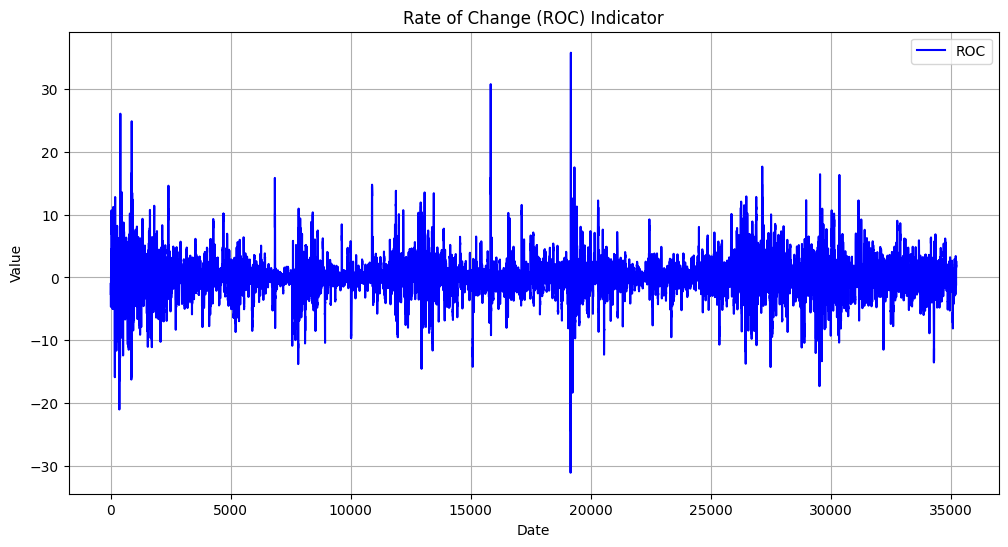

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
from ta.momentum import ROCIndicator

# Assuming you have initial_df already defined with a 'Close' column
# Calculate the ROC indicator for initial_df
roc = ROCIndicator(close=initial_df['close'], window=12, fillna=False)

# Access the ROC values
roc_values = roc.roc()

# Create a DataFrame to store the ROC values along with the index
roc_df = pd.DataFrame({
    'ROC': roc_values,
}, index=initial_df.index)

# Plot the ROC indicator
plt.figure(figsize=(12, 6))
plt.plot(roc_df.index, roc_df['ROC'], label='ROC', color='blue')

plt.title('Rate of Change (ROC) Indicator')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


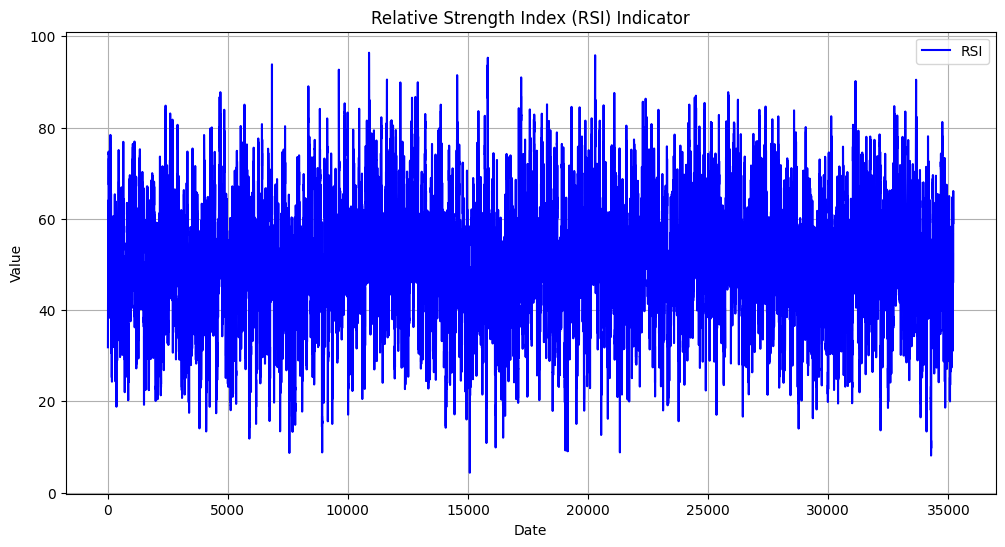

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
from ta.momentum import RSIIndicator

# Assuming you have initial_df already defined with a 'Close' column
# Calculate the RSI indicator for initial_df
rsi = RSIIndicator(close=initial_df['close'], window=14, fillna=False)

# Access the RSI values
rsi_values = rsi.rsi()

# Create a DataFrame to store the RSI values along with the index
rsi_df = pd.DataFrame({
    'RSI': rsi_values,
}, index=initial_df.index)

# Plot the RSI indicator
plt.figure(figsize=(12, 6))
plt.plot(rsi_df.index, rsi_df['RSI'], label='RSI', color='blue')

plt.title('Relative Strength Index (RSI) Indicator')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


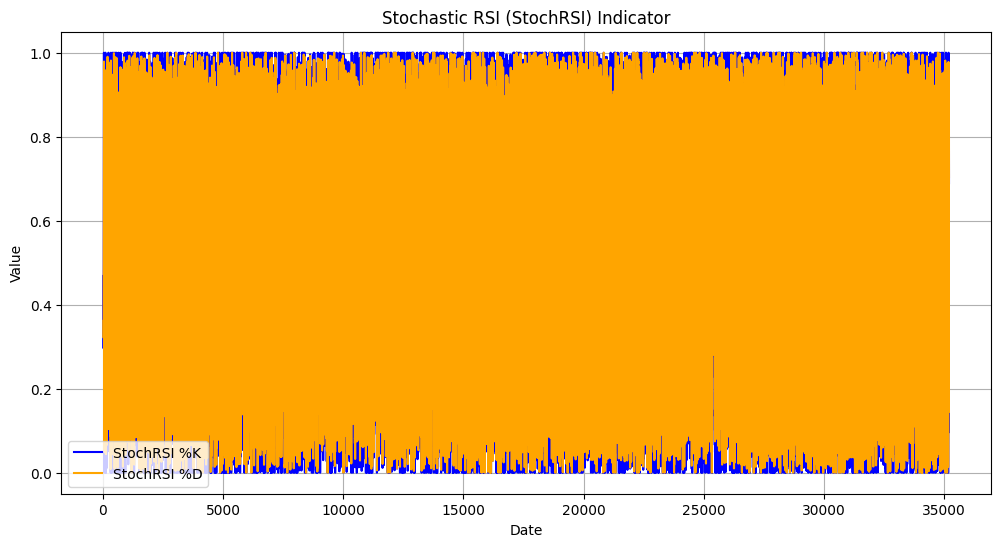

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
from ta.momentum import StochRSIIndicator

# Assuming you have initial_df already defined with a 'Close' column
# Calculate the StochRSI indicator for initial_df
stochrsi = StochRSIIndicator(close=initial_df['close'], window=14, smooth1=3, smooth2=3, fillna=False)

# Access the StochRSI %K and %D values
stochrsi_k = stochrsi.stochrsi_k()
stochrsi_d = stochrsi.stochrsi_d()

# Create a DataFrame to store the StochRSI %K and %D values along with the index
stochrsi_df = pd.DataFrame({
    'StochRSI %K': stochrsi_k,
    'StochRSI %D': stochrsi_d
}, index=initial_df.index)




# Plot the StochRSI indicator
plt.figure(figsize=(12, 6))
plt.plot(stochrsi_df.index, stochrsi_df['StochRSI %K'], label='StochRSI %K', color='blue')
plt.plot(stochrsi_df.index, stochrsi_df['StochRSI %D'], label='StochRSI %D', color='orange')

plt.title('Stochastic RSI (StochRSI) Indicator')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


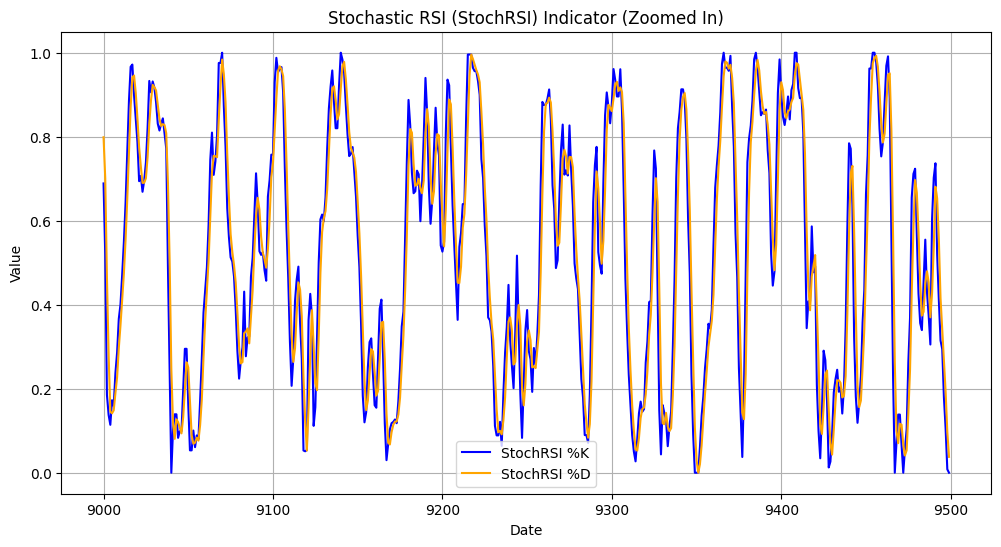

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
from ta.momentum import StochRSIIndicator

# Assuming you have initial_df already defined with a 'Close' column
# Calculate the StochRSI indicator for initial_df
stochrsi = StochRSIIndicator(close=initial_df['close'], window=14, smooth1=3, smooth2=3, fillna=False)

# Access the StochRSI %K and %D values
stochrsi_k = stochrsi.stochrsi_k()
stochrsi_d = stochrsi.stochrsi_d()

# Create a DataFrame to store the StochRSI %K and %D values along with the index
stochrsi_df = pd.DataFrame({
    'StochRSI %K': stochrsi_k,
    'StochRSI %D': stochrsi_d
}, index=initial_df.index)

# Define the date range you want to plot (e.g., from index 9000 to 9500)
start_date = 9000
end_date = 9500

# Plot the StochRSI indicator for the specified date range
plt.figure(figsize=(12, 6))
plt.plot(stochrsi_df.index[start_date:end_date], stochrsi_df['StochRSI %K'][start_date:end_date], label='StochRSI %K', color='blue')
plt.plot(stochrsi_df.index[start_date:end_date], stochrsi_df['StochRSI %D'][start_date:end_date], label='StochRSI %D', color='orange')

plt.title('Stochastic RSI (StochRSI) Indicator (Zoomed In)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


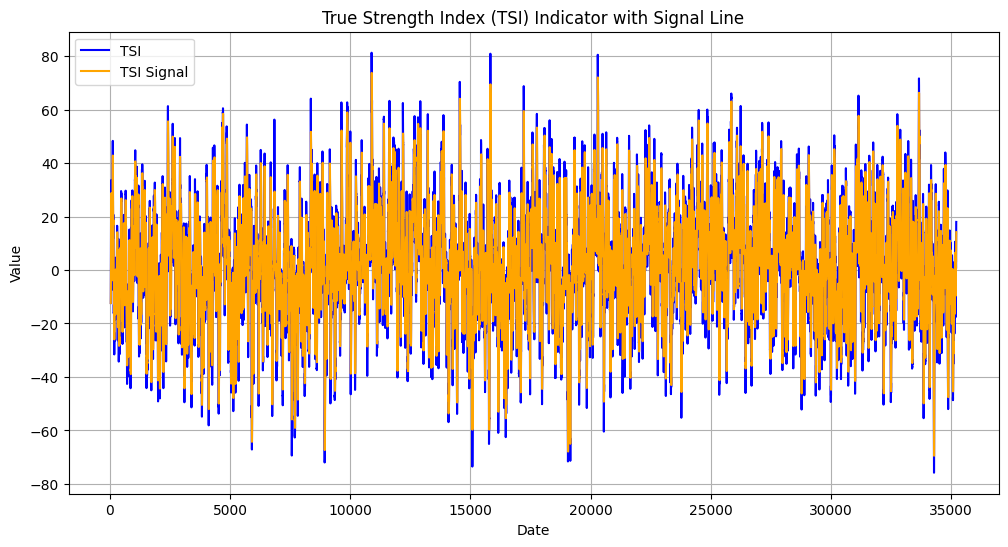

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
from ta.momentum import TSIIndicator

# Assuming you have initial_df already defined with a 'Close' column
# Calculate the TSI indicator for initial_df
tsi = TSIIndicator(close=initial_df['close'], window_slow=25, window_fast=13, fillna=False)

# Access the TSI values
tsi_values = tsi.tsi()

# Calculate the TSI signal line as the EMA of the TSI values
tsi_signal = tsi_values.ewm(span=9, adjust=False).mean()

# Create a DataFrame to store the TSI values and signal line along with the index
tsi_df = pd.DataFrame({
    'TSI': tsi_values,
    'TSI Signal': tsi_signal,
}, index=initial_df.index)

# Plot the TSI indicator and its signal line
plt.figure(figsize=(12, 6))
plt.plot(tsi_df.index, tsi_df['TSI'], label='TSI', color='blue')
plt.plot(tsi_df.index, tsi_df['TSI Signal'], label='TSI Signal', color='orange')

plt.title('True Strength Index (TSI) Indicator with Signal Line')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


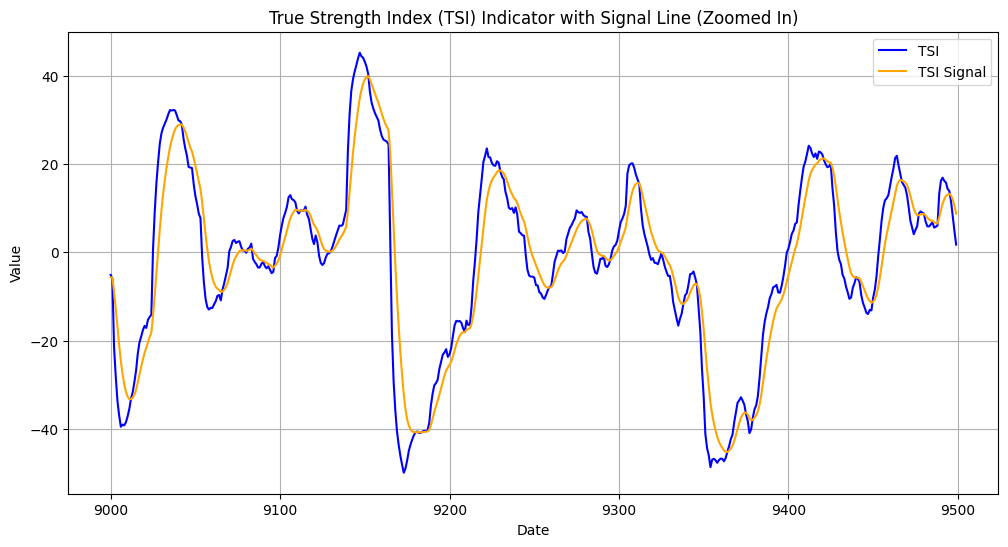

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
from ta.momentum import TSIIndicator

# Assuming you have initial_df already defined with a 'Close' column
# Calculate the TSI indicator for initial_df
tsi = TSIIndicator(close=initial_df['close'], window_slow=25, window_fast=13, fillna=False)

# Access the TSI values
tsi_values = tsi.tsi()

# Calculate the TSI signal line as the EMA of the TSI values
tsi_signal = tsi_values.ewm(span=9, adjust=False).mean()

# Create a DataFrame to store the TSI values and signal line along with the index
tsi_df = pd.DataFrame({
    'TSI': tsi_values,
    'TSI Signal': tsi_signal,
}, index=initial_df.index)

# Define the date range you want to plot (e.g., from index 9000 to 9500)
start_date = 9000
end_date = 9500

# Plot the TSI indicator and its signal line for the specified date range
plt.figure(figsize=(12, 6))
plt.plot(tsi_df.index[start_date:end_date], tsi_df['TSI'][start_date:end_date], label='TSI', color='blue')
plt.plot(tsi_df.index[start_date:end_date], tsi_df['TSI Signal'][start_date:end_date], label='TSI Signal', color='orange')

plt.title('True Strength Index (TSI) Indicator with Signal Line (Zoomed In)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


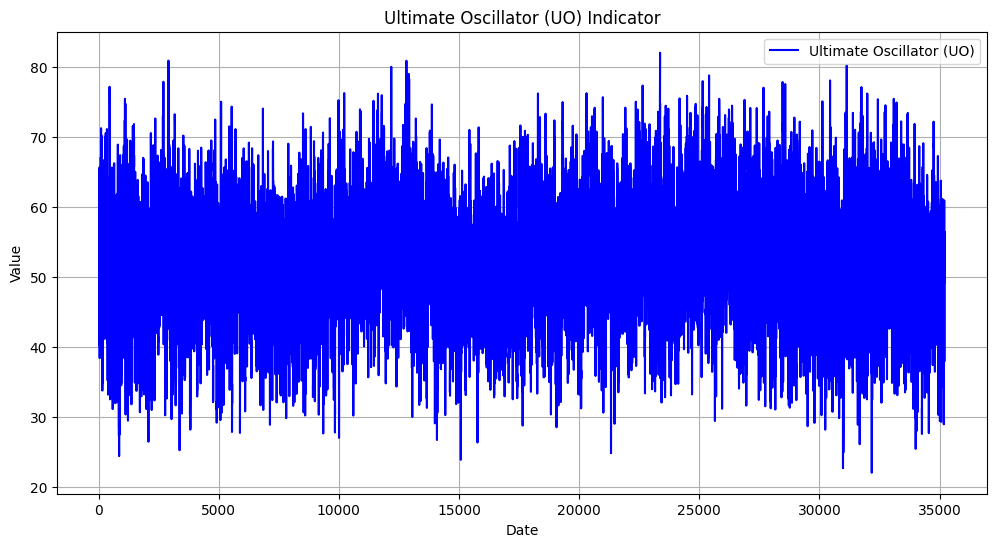

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
from ta.momentum import UltimateOscillator

# Assuming you have initial_df already defined with 'High', 'Low', and 'Close' columns
# Calculate the Ultimate Oscillator for initial_df
uo = UltimateOscillator(high=initial_df['high'], low=initial_df['low'], close=initial_df['close'],
                        window1=7, window2=14, window3=28, weight1=4.0, weight2=2.0, weight3=1.0, fillna=False)

# Access the UO values
uo_values = uo.ultimate_oscillator()

# Create a DataFrame to store the UO values along with the index
uo_df = pd.DataFrame({
    'Ultimate Oscillator (UO)': uo_values
}, index=initial_df.index)

# Plot the Ultimate Oscillator
plt.figure(figsize=(12, 6))
plt.plot(uo_df.index, uo_df['Ultimate Oscillator (UO)'], label='Ultimate Oscillator (UO)', color='blue')

plt.title('Ultimate Oscillator (UO) Indicator')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


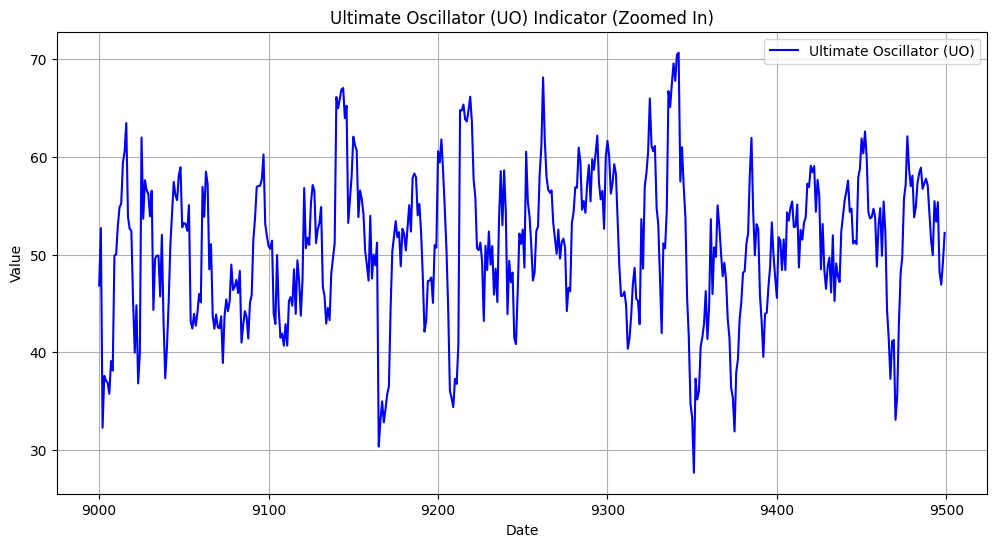

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
from ta.momentum import UltimateOscillator

# Assuming you have initial_df already defined with 'High', 'Low', and 'Close' columns
# Calculate the Ultimate Oscillator for initial_df
uo = UltimateOscillator(high=initial_df['high'], low=initial_df['low'], close=initial_df['close'],
                        window1=7, window2=14, window3=28, weight1=4.0, weight2=2.0, weight3=1.0, fillna=False)

# Access the UO values
uo_values = uo.ultimate_oscillator()

# Create a DataFrame to store the UO values along with the index
uo_df = pd.DataFrame({
    'Ultimate Oscillator (UO)': uo_values
}, index=initial_df.index)

# Define the range you want to plot (e.g., from index 9000 to 9500)
start_index = 9000
end_index = 9500

# Plot the Ultimate Oscillator for the specified range
plt.figure(figsize=(12, 6))
plt.plot(uo_df.index[start_index:end_index], uo_df['Ultimate Oscillator (UO)'][start_index:end_index],
         label='Ultimate Oscillator (UO)', color='blue')

plt.title('Ultimate Oscillator (UO) Indicator (Zoomed In)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


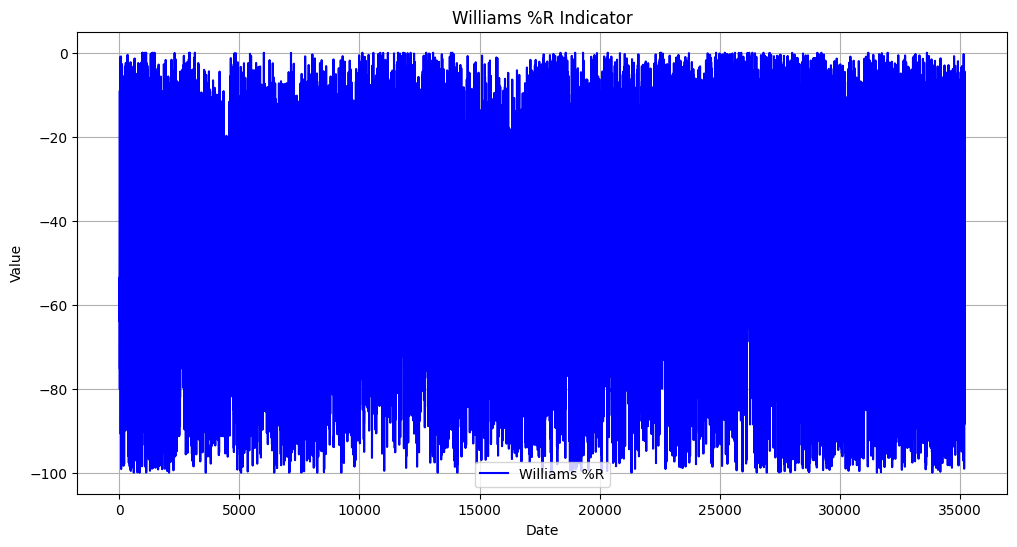

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
from ta.momentum import WilliamsRIndicator

# Assuming you have initial_df already defined with 'High', 'Low', and 'Close' columns
# Calculate the Williams %R indicator for initial_df
williams_r = WilliamsRIndicator(high=initial_df['high'], low=initial_df['low'], close=initial_df['close'], lbp=14, fillna=False)

# Access the Williams %R values
williams_r_values = williams_r.williams_r()

# Create a DataFrame to store the Williams %R values along with the index
williams_r_df = pd.DataFrame({
    'Williams %R': williams_r_values
}, index=initial_df.index)

# Plot the Williams %R indicator
plt.figure(figsize=(12, 6))
plt.plot(williams_r_df.index, williams_r_df['Williams %R'], label='Williams %R', color='blue')

plt.title('Williams %R Indicator')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


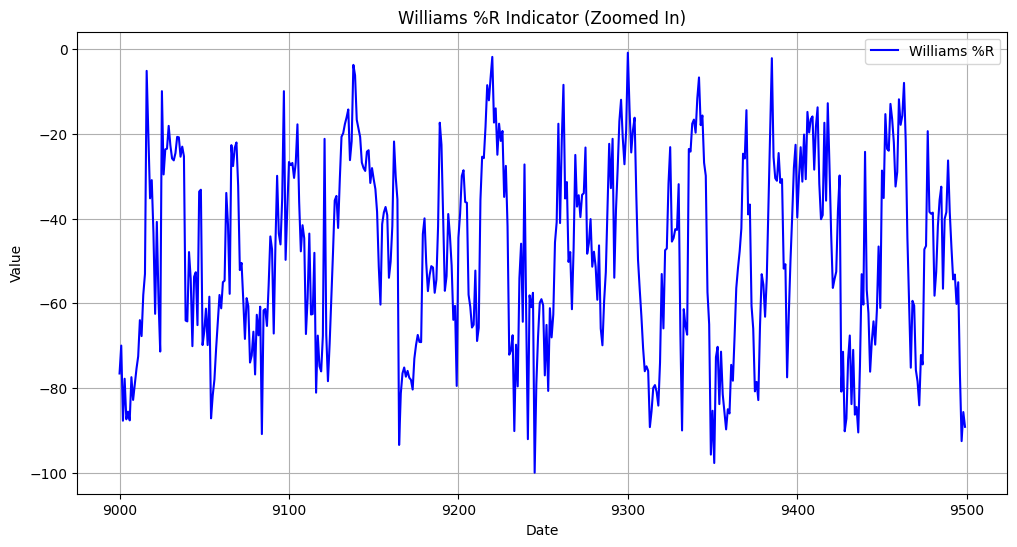

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
from ta.momentum import WilliamsRIndicator

# Assuming you have initial_df already defined with 'High', 'Low', and 'Close' columns
# Calculate the Williams %R indicator for initial_df
williams_r = WilliamsRIndicator(high=initial_df['high'], low=initial_df['low'], close=initial_df['close'], lbp=14, fillna=False)

# Access the Williams %R values
williams_r_values = williams_r.williams_r()

# Create a DataFrame to store the Williams %R values along with the index
williams_r_df = pd.DataFrame({
    'Williams %R': williams_r_values
}, index=initial_df.index)

# Define the range you want to plot (e.g., from index 9000 to 9500)
start_index = 9000
end_index = 9500

# Plot the Williams %R for the specified range
plt.figure(figsize=(12, 6))
plt.plot(williams_r_df.index[start_index:end_index], williams_r_df['Williams %R'][start_index:end_index],
         label='Williams %R', color='blue')

plt.title('Williams %R Indicator (Zoomed In)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


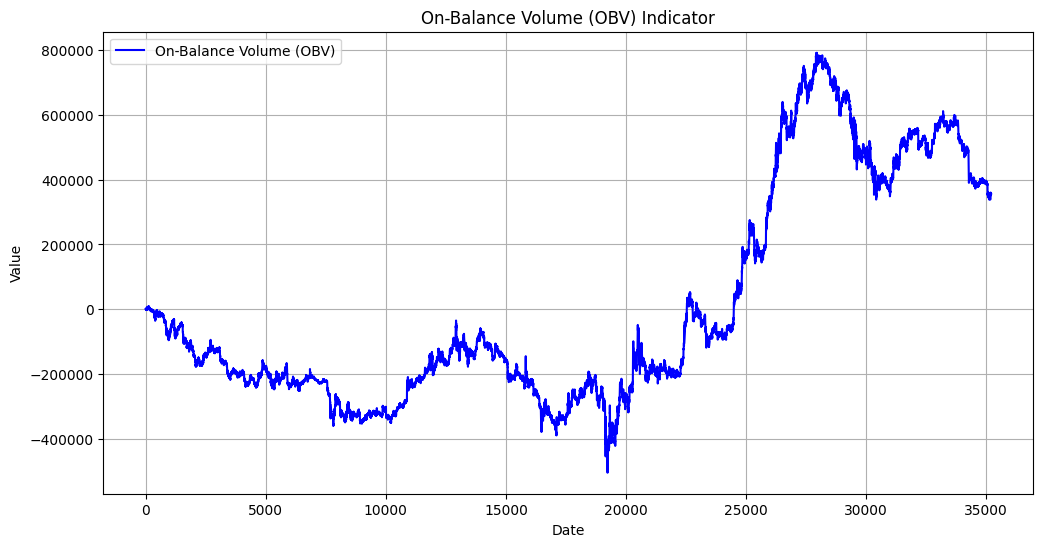

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
from ta.volume import OnBalanceVolumeIndicator

# Assuming you have initial_df already defined with 'Close' and 'Volume' columns
# Calculate the On-Balance Volume (OBV) indicator for initial_df
obv = OnBalanceVolumeIndicator(close=initial_df['close'], volume=initial_df['volume'], fillna=False)

# Access the OBV values
obv_values = obv.on_balance_volume()

# Create a DataFrame to store the OBV values along with the index
obv_df = pd.DataFrame({
    'On-Balance Volume (OBV)': obv_values
}, index=initial_df.index)

# Plot the On-Balance Volume (OBV) indicator
plt.figure(figsize=(12, 6))
plt.plot(obv_df.index, obv_df['On-Balance Volume (OBV)'], label='On-Balance Volume (OBV)', color='blue')

plt.title('On-Balance Volume (OBV) Indicator')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


# Calculating Signals

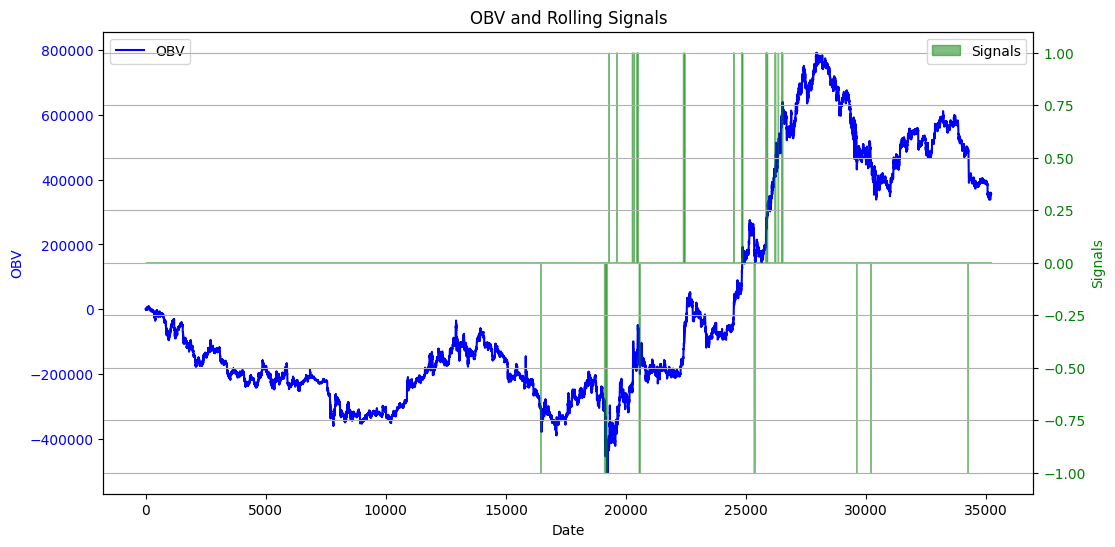

,datetime,open,high,low,close,volume,OBV_Signals
0,2018-01-01 05:30:00,13715.65,13715.65,13400.01,13529.01,443.356199,0
1,2018-01-01 06:30:00,13528.99,13595.89,13155.38,13203.06,383.697006,0
2,2018-01-01 07:30:00,13203.00,13418.43,13200.00,13330.18,429.064572,0
3,2018-01-01 08:30:00,13330.26,13611.27,13290.00,13410.03,420.087030,0
4,2018-01-01 09:30:00,13434.98,13623.29,13322.15,13601.01,340.807329,0
...,...,...,...,...,...,...,...
35203,2022-01-12 01:30:00,42972.04,43095.26,42692.19,42800.38,1219.601780,0
35204,2022-01-12 02:30:00,42797.62,42823.69,42643.74,42659.20,702.103800,0
35205,2022-01-12 03:30:00,42664.71,42776.14,42597.41,42713.13,561.859930,0
35206,2022-01-12 04:30:00,42713.12,42886.28,42633.97,42729.29,681.142010,0


In [107]:
import pandas as pd
import matplotlib.pyplot as plt
from ta.volume import OnBalanceVolumeIndicator

# Define a rolling window size and threshold
window_size = 100
threshold = 100000

indicator_values = obv_values

# Create a DataFrame to store the OBV values along with the index
indicator_df = pd.DataFrame({'OBV': indicator_values}, index=initial_df.index)

# Function to generate rolling signals
def generate_rolling_signals(indicator_df, window_size):
    signals = []

    for i in range(len(indicator_df)):
        if i < window_size:
            signals.append(0)  # Not enough data for the rolling window
        else:
            window_start = i - (window_size // 2)  # 50 hours before
            window_end = i + (window_size // 2)  # 50 hours after
            window_values = indicator_df.iloc[window_start:window_end]

            diff = window_values.iloc[-1] - window_values.iloc[0]

            if diff > threshold:
                signals.append(1)  # Increasing behavior
            elif diff < -threshold:
                signals.append(-1)  # Decreasing behavior
            else:
                signals.append(0)  # No clear trend

    return pd.Series(signals, index=indicator_df.index)

# Generate rolling signals
indicator_signals = generate_rolling_signals(indicator_df['OBV'], window_size)

# Create a subplot with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot OBV values on the first y-axis
ax1.plot(indicator_df.index, indicator_df['OBV'], label='OBV', color='blue')
ax1.set_xlabel('Date')
ax1.set_ylabel('OBV', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

# Create a second y-axis for the signals
ax2 = ax1.twinx()
ax2.fill_between(indicator_signals.index, indicator_signals.values, 0, alpha=0.5, label='Signals', color='green')
ax2.set_ylabel('Signals', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.legend(loc='upper right')

plt.title('OBV and Rolling Signals')
plt.grid(True)
plt.show()


initial_df['OBV_Signals'] = indicator_signals
initial_df
